Generate a magnetic field diagram in matplotlib
From Google 

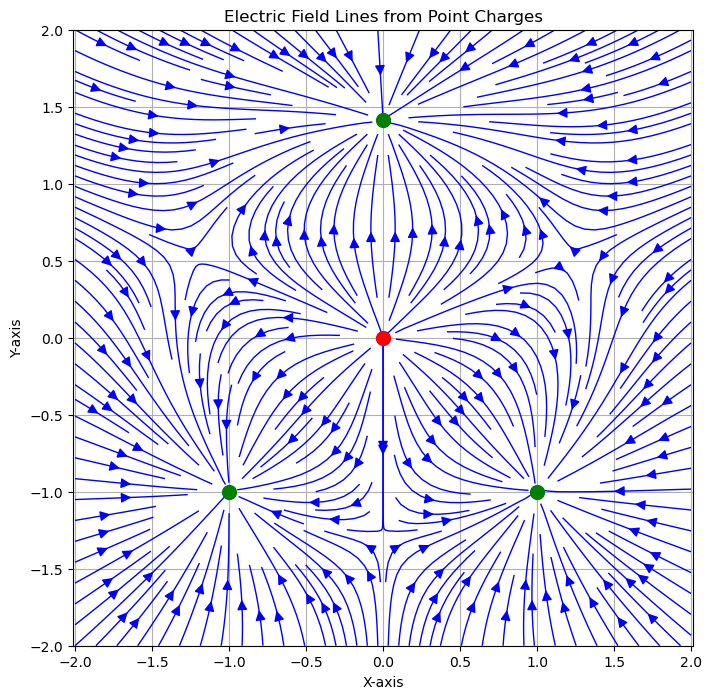

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Define the charges and their positions
charges = [
    {'q': 1, 'pos': (0, 0)},  # Positive charge at (0, 1)
    {'q': -1, 'pos': (1, -1)}, # Negative charge at (0, -1)
    {'q': -1, 'pos': (0, np.sqrt(2))}, # Negative charge at (0, -1)
    {'q': -1, 'pos': (-1, -1)} # Negative charge at (0, -1)
]

# Create a grid for the field calculation
x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)

# Calculate the electric field components (Ex, Ey)
Ex = np.zeros_like(X)
Ey = np.zeros_like(Y)

for charge in charges:
    q = charge['q']
    qx, qy = charge['pos']

    # Calculate distance squared from each point on the grid to the charge
    r_squared = (X - qx)**2 + (Y - qy)**2
    
    # Avoid division by zero at the charge location
    r_squared[r_squared == 0] = np.inf 

    # Calculate electric field components due to each charge
    Ex += q * (X - qx) / (r_squared**1.5)
    Ey += q * (Y - qy) / (r_squared**1.5)

# Normalize the field vectors for consistent arrow length in streamplot
# This helps in visualizing the direction clearly without being overwhelmed by magnitude differences
E_magnitude = np.sqrt(Ex**2 + Ey**2)
Ex_norm = Ex / E_magnitude
Ey_norm = Ey / E_magnitude

# Create the plot
plt.figure(figsize=(8, 8))

# Plot the field lines using streamplot
plt.streamplot(X, Y, Ex_norm, Ey_norm, color='blue', linewidth=1, density=2, arrowsize=1.5)

# Plot the charges
for charge in charges:
    color = 'red' if charge['q'] > 0 else 'green'
    plt.plot(charge['pos'][0], charge['pos'][1], 'o', color=color, markersize=10)

plt.title('Electric Field Lines from Point Charges')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid(True)
plt.axis('equal') # Ensure equal scaling for x and y axes
plt.show()